# Demo
This notebook aims to demo some functionality for new members onboarding

In [2]:
%load_ext autoreload
%autoreload 2

## Remote simulator

In [2]:
from config_loader import CONFIG
from remote import PS5Remote, RemoteSimulator
from logger import Logger, LogLevels

remote = PS5Remote(Logger(identifier="remote"))
simulator = RemoteSimulator(remote)
simulator.run()
print("Simulation is running on a separate window")


ImportError: cannot import name 'PS5Remote' from 'remote' (unknown location)

# Planification des taches

## Optimisation des tâches

### Algorithme

Considérons un problème d'optimisation combinatoire appliqué à la planification de tâches d'un robot mobile. Le problème se définit ainsi : étant donné un ensemble de $n$ tâches, une position initiale $p_0$ et une position finale $p_f$, nous cherchons à déterminer une séquence optimale de tâches à exécuter. Chaque tâche est caractérisée par trois paramètres : un score $s$, un temps d'exécution $t_e$, et une position terminale $p$ dans l'espace de travail du robot. Le temps de déplacement $t_t$ entre deux positions successives est calculé via une fonction $f: \mathbb{R}^2 \times \mathbb{R}^2 \rightarrow \mathbb{R}$ qui associe à deux positions $p_a$ et $p_b$ un temps $t$.

Reformulons ce problème :

Soit $G=(V,E)$ un graphe complet pondéré où chaque arête $(u,v)∈E$ est associée à un coût $c_d(u,v)\in ℕ$. De plus, chaque sommet $v∈V$ possède deux attributs : un score $s(v)$ et un coût $c_t(v)$.

L'objectif est de déterminer un chemin $v_0$→$v_f$, maximisant la somme des scores des sommets visités, tout en respectant une contrainte de coût total. Plus précisément, la somme des coûts des sommets et des arêtes parcourus, définie comme :

$$
C = \sum_{(u,v) \in E'} c_d(u,v) + \sum_{v \in V'} c_t(v)
$$

doit être inférieure ou égale à un seuil $M$, où $E'$ et $V'$ représentent respectivement les arêtes et les sommets de la chaine sélectionnée.

### Implémentation

Supposons qu'on ait $n$ tâches, on aura donc $n+2$ sommets dans notre graph. En effet les points de départ et d'arrivée ne sont pas définis comme des tâches. Les déplacements vers l'origine et la destination sont donc gérés comme des cas particuliers.

Lorsqu'on lance la planification des tâches on considère la position actuelle du robot comme la position initiale et une variable final_goal défini la position finale.

Pour le moment on considère que le trajet de A à B est de même durée donc que le graph est non orienté. Par conséquent si le profil pour aller à B est différent de celui pour aller à A la simulation ne représente pas le comportement réel. Pour arriver à une simulation exacte il faudrait transformé notre solveur pour qu'il se comporte comme un graph 

In [37]:
from config_loader import CONFIG
from tasks import Task
from brains import MainBrain

### Demo

23:30:29.167316 -> [   WS_Server   ] [  server.py  :48]    INFO    | Initialized with host: 0.0.0.0, port: 8080
23:30:29.167316 -> [WS_cmd_Receiver] [ receiver.py :36]    INFO    | Initialized: use_queue: True, keep_memory: False
23:30:29.167316 -> [ WS_cmd_Sender ] [  sender.py  :33]    INFO    | Initialized with name: rob
23:30:29.167316 -> [WS_cmd_RouteM..] [server_rout..:38]    INFO    | Initialized with only_unique_client_name: False
23:30:29.167316 -> [   WS_Server   ] [  server.py  :88]    INFO    | New route handler added [/cmd], route url: [ws://0.0.0.0:8080/cmd]
23:30:29.182971 -> [     Lidar     ] [lidar_dummy..:48]    INFO    | [LidarDummy] Initialized successfully.
23:30:29.244006 -> [GridMan..] [decorators.py:41]   DEBUG    | [grid_manager] GridManager.__mark_zone(self=<arena.base_..., grid=<Grid width=..., polygon_to_mark=<POLYGON ((2..., walkable=False) executed in 0.051014s
23:30:29.245020 -> [GridMan..] [decorators.py:41]   DEBUG    | [arena] GridManager.add_forbidden

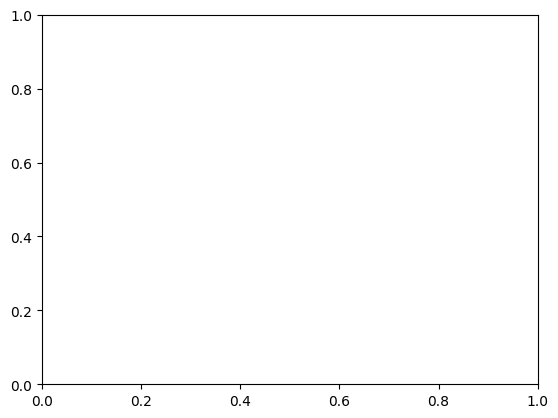

In [ ]:
# ====== Imports ======
# Config
from config_loader import CONFIG

# Logger: LoggerManager + global configuration
from loggerplusplus import LoggerManager, LogLevels, LoggerConfig, Logger, logger_colors

LoggerManager.enable_files_logs_monitoring_only_for_one_logger = (
    CONFIG.LOGGER_MANAGER_ENABLE_FILES_LOGS_MONITORING_ONLY_FOR_ONE_LOGGER
)
LoggerManager.enable_dynamic_config_update = CONFIG.LOGGER_MANAGER_ENABLE_DYNAMIC_CONFIG_UPDATE
LoggerManager.enable_unique_logger_identifier = CONFIG.LOGGER_MANAGER_ENABLE_UNIQUE_LOGGER_IDENTIFIER

LoggerManager.global_config = LoggerConfig.from_kwargs(
    colors=getattr(logger_colors, CONFIG.LOGGER_COLORS),
    path=CONFIG.LOGGER_PATH,
    # LogLevels
    decorator_log_level=getattr(LogLevels, CONFIG.LOGGER_DECORATOR_LOG_LEVEL),
    print_log_level=getattr(LogLevels, CONFIG.LOGGER_PRINT_LOG_LEVEL),
    file_log_level=getattr(LogLevels, CONFIG.LOGGER_FILE_LOG_LEVEL),
    # Loggers Output
    print_log=CONFIG.LOGGER_PRINT_LOG,
    write_to_file=CONFIG.LOGGER_WRITE_TO_FILE,
    # Monitoring
    display_monitoring=CONFIG.LOGGER_DISPLAY_MONITORING,
    files_monitoring=CONFIG.LOGGER_FILES_MONITORING,
    file_size_unit=CONFIG.LOGGER_FILE_SIZE_UNIT,
    disk_alert_threshold_percent=CONFIG.LOGGER_DISK_ALERT_THRESHOLD_PERCENT,
    log_files_size_alert_threshold_percent=CONFIG.LOGGER_FILES_SIZE_ALERT_THRESHOLD_PERCENT,
    max_log_file_size=CONFIG.LOGGER_MAX_LOG_FILE_SIZE,
    # Placement
    identifier_max_width=CONFIG.LOGGER_IDENTIFIER_MAX_WIDTH,
    filename_lineno_max_width=CONFIG.LOGGER_FILENAME_LINENO_MAX_WIDTH,
)

# ====== Local Library Imports ======
from ws_comms import WServer, WServerRouteManager, WSender, WSreceiver
from arena import ShowArena, AllyZone
from geometry import OrientedPoint
from brains import MainBrain
from taskbrain import DictProxyAccessor
from movement import GoToParams
from sensors import Lidar, LidarDummy

# ====== Main ======
if __name__ == "__main__":
    """
    ###--- Initialization ---###
    """

    """ Loggers """
    # System-Part loggers
    logger_ws_server = Logger(
        identifier="WS_Server",
        follow_logger_manager_rules=True,
    )
    logger_ws_cmd_route_manager = Logger(
        identifier="WS_cmd_RouteManager",
        follow_logger_manager_rules=True,
    )
    logger_ws_cmd_sender = Logger(
        identifier="WS_cmd_Sender",
        follow_logger_manager_rules=True,
    )
    logger_ws_cmd_receiver = Logger(
        identifier="WS_cmd_Receiver",
        follow_logger_manager_rules=True,
    )
    logger_brain = Logger(
        identifier="Brain",
        # Only Brain manages monitoring
        files_monitoring=True,
        display_monitoring=True,
        print_log_level=LogLevels.DEBUG,
        follow_logger_manager_rules=True,
    )
    logger_lidar = Logger(
        identifier="Lidar",
        follow_logger_manager_rules=True,
    )

    # Controllers loggers
    # See ./brains/controllers_brain.py for more details
    # All rolling basis part is executed in another process so define inside this part

    # Environment loggers
    logger_grid_manager = Logger(
        identifier="GridManager",
        follow_logger_manager_rules=True,
    )
    logger_show_arena = Logger(
        identifier="ShowArena",
        follow_logger_manager_rules=True,
    )

    # Movement loggers
    # See ./brains/controllers_brain.py for more details
    # All rolling basis part is executed in another process so define inside this part

    """ Main object instances """
    # Websocket server
    # Websocket server
    ws_server = WServer(
        logger=logger_ws_server,
        host=CONFIG.WS_HOSTNAME,
        port=CONFIG.WS_PORT,
        # ping_pong_clients_interval=CONFIG.WS_PING_PONG_INTERVAL,  # TODO: To fix, this feature is not working
    )
    # Routes
    ws_cmd = WServerRouteManager(
        logger=logger_ws_cmd_route_manager,
        receiver=WSreceiver(logger=logger_ws_cmd_receiver, use_queue=True),
        sender=WSender(logger=logger_ws_cmd_sender, name=CONFIG.WS_SENDER_NAME)
    )
    ws_server.add_route_handler(CONFIG.WS_CMD_ROUTE, ws_cmd)

    # Controllers
    # Rolling Basis
    # See ./brains/controllers_brain.py for more details
    # All rolling basis part is executed in another process so define inside this part

    # Sensors
    # Lidar
    lidar = LidarDummy(
        logger=logger_lidar,
        min_angle=CONFIG.LIDAR_MIN_ANGLE,
        max_angle=CONFIG.LIDAR_MAX_ANGLE,
        unit_angle=CONFIG.LIDAR_ANGLES_UNIT,
        unit_distance=CONFIG.LIDAR_DISTANCES_UNIT,
        min_distance=CONFIG.LIDAR_MIN_DISTANCE_DETECTION,
    )

    # Environment
    # Arena
    arena = ShowArena(
        logger=logger_show_arena,
        border_buffer=CONFIG.ARENA_BORDER_BUFFER,
        obstacle_buffer=CONFIG.ARENA_OBSTACLE_BUFFER,
        chunk_size=CONFIG.ARENA_CHUNK_SIZE,
        forbidden_cover_threshold=CONFIG.ARENA_FORBIDDEN_COVER_THRESHOLD,
        grid_manager_logger=logger_grid_manager,
    )

    # Movement
    # Movement manager
    # See ./brains/controllers_brain.py for more details
    # All rolling basis part is executed in another process so define inside this part

    # Brain
    # Add all object type which need to be shared between processes in the DictProxyAccessor serializable types list
    DictProxyAccessor.add_serializable_type(ShowArena, arena)
    DictProxyAccessor.add_serializable_type(OrientedPoint)
    DictProxyAccessor.add_serializable_type(GoToParams)
    DictProxyAccessor.add_serializable_type(AllyZone)

    brain = MainBrain(
        logger=logger_brain,
        lidar=lidar,
        arena=arena,
        ws_cmd=ws_cmd,
    )


23:30:35.156340 -> [     debug     ] [main_brain..:284]  CRITICAL  | Computing travel from start to task 1
23:30:35.176587 -> [   PathFinder  ] [path_finde..:114]  WARNING   | No path found! Grid: [start=(30, 20), goal=(21, 30)] Absolute: [start=(150.0, 100.0), goal=(105.0, 154.0)] | exploration_value=1038
23:30:35.178587 -> [MovementManager] [trajectory..:416]  WARNING   | No path found !
23:30:35.179597 -> [     debug     ] [main_brain..:296]  CRITICAL  | Computing travel task 1 to destination
23:30:35.188676 -> [   PathFinder  ] [path_finde..:114]  WARNING   | No path found! Grid: [start=(30, 20), goal=(21, 30)] Absolute: [start=(150.0, 100.0), goal=(105.0, 154.0)] | exploration_value=1038
23:30:35.188676 -> [MovementManager] [trajectory..:416]  WARNING   | No path found !
23:30:35.188676 -> [     debug     ] [main_brain..:284]  CRITICAL  | Computing travel from start to task 2
23:30:35.209342 -> [   PathFinder  ] [path_finde..:114]  WARNING   | No path found! Grid: [start=(30, 20),

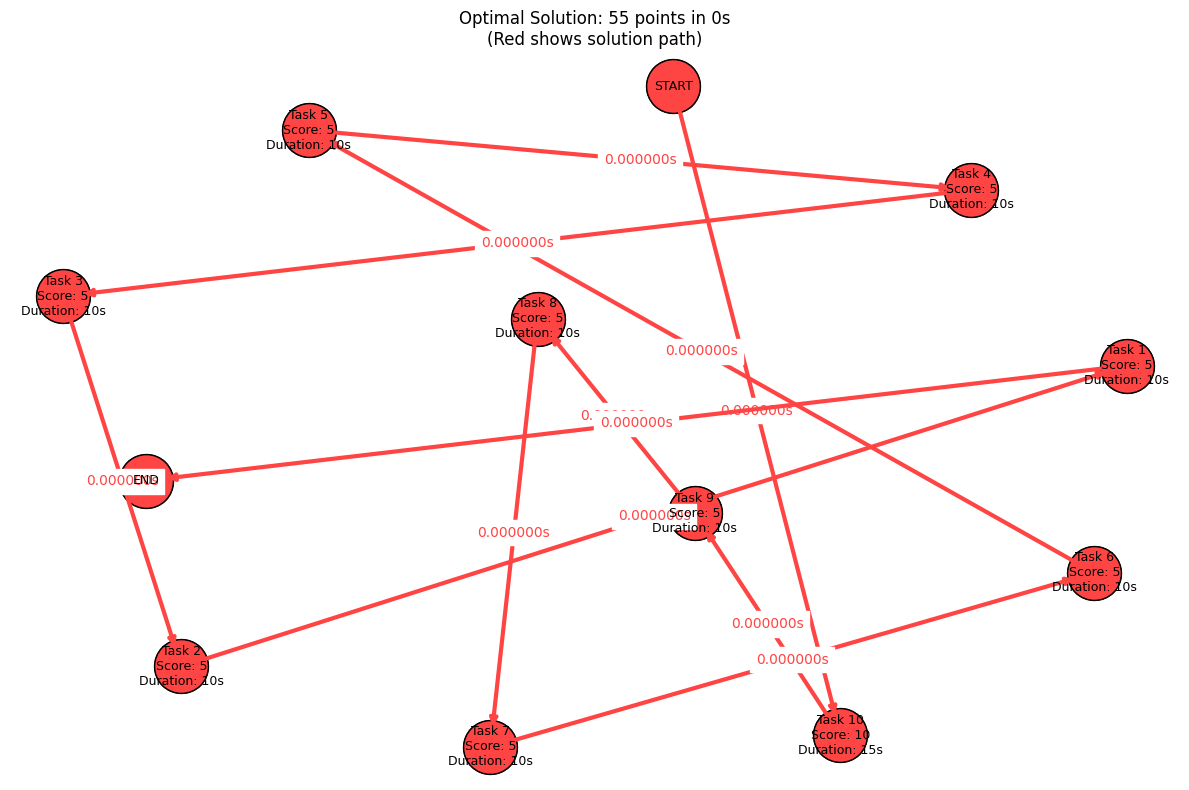

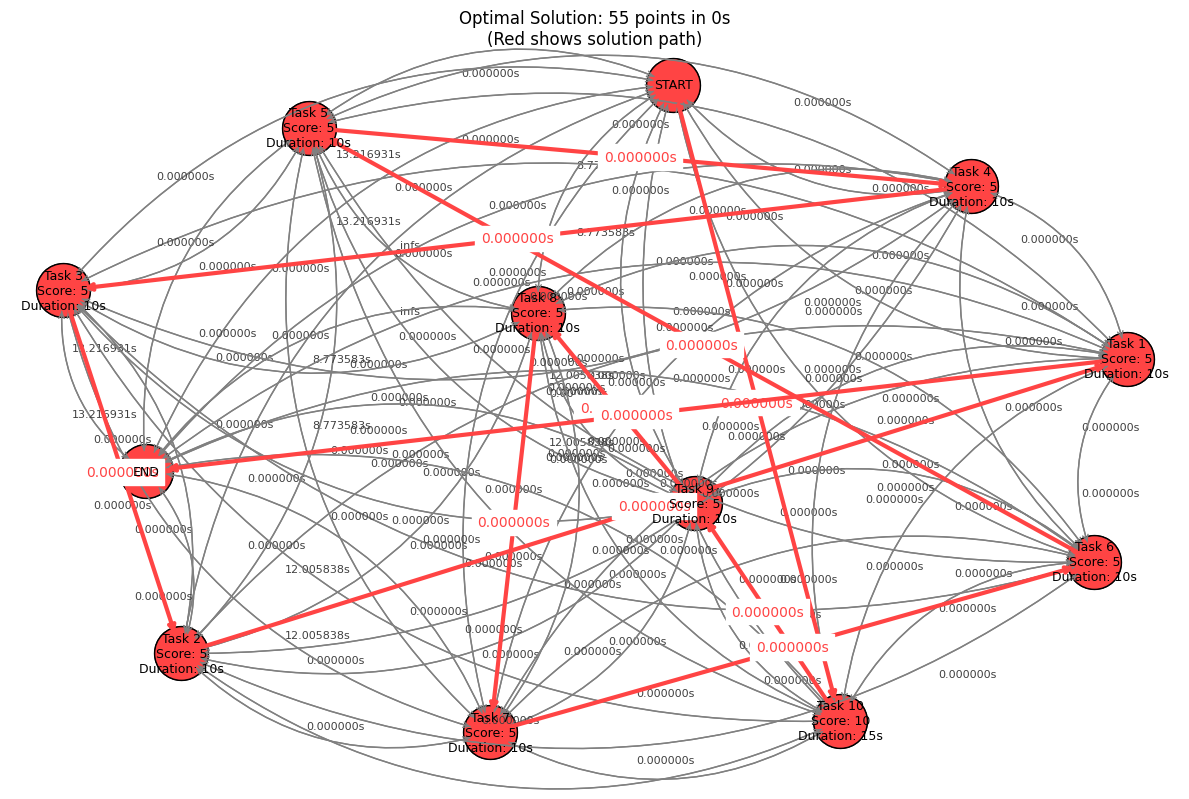

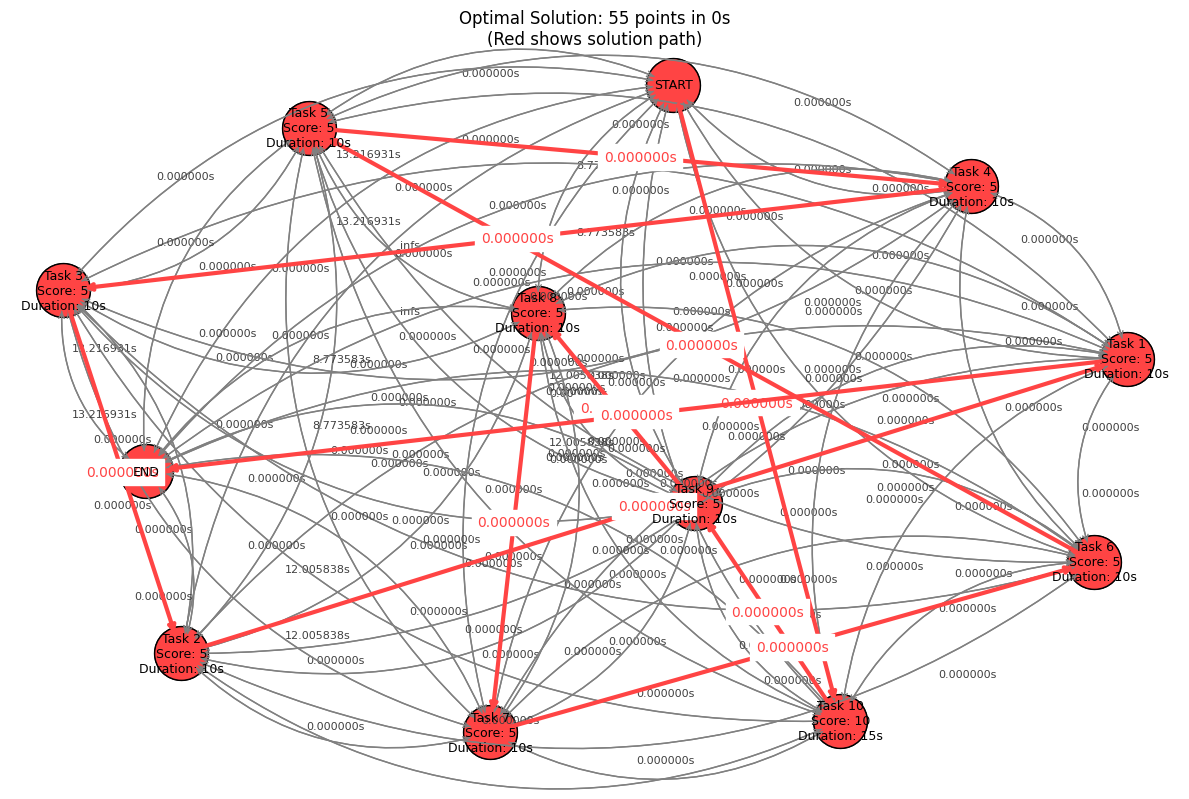

In [47]:
from config_loader import CONFIG
from brains import MainBrain
from tasks import Task
from geometry import Point,OrientedPoint,OrientedPoint
import gc
from movement import TrajectoryParams,SpeedProfile,GoToParams
import random


if __name__ == "__main__":
    goals = [
        OrientedPoint(136, 104, 0.0),
        OrientedPoint(105, 154, 0.0),
        OrientedPoint(51, 77, 0.0),
        OrientedPoint(204, 130, 0.0),
        OrientedPoint(150, 100, 0.0),
        OrientedPoint(125, 29, 0.0),
        OrientedPoint(39, 18, 0.0),
        OrientedPoint(107, 72, 0.0),
        OrientedPoint(143, 137, 0.0)
    ]
    game_tasks = [
        Task (
            action_func=lambda: f"action {i}",
            start_func=lambda: print(f"action start {i}"),
            name=f"task{i}",
            execution_time=10,
            score=5,
            go_to_params=GoToParams(
                trajectory_params = TrajectoryParams(
                    speed_profile=SpeedProfile(**CONFIG.SPECIFIC_CONFIG["rolling_basis"]["speed_profiles"]["default"]),
                    goal = goals[i],
                    resolution = CONFIG.SPECIFIC_CONFIG["movement_manager"]["movement_resolution"]
                ),
                acs_distance=20,
                path_finder_recompute_distance=8,
            )
        ) for i in range(9)
    ]
    
    game_tasks.append(
        Task(
            action_func=lambda: "action 9",
            start_func=lambda: print("action start 9"),
            name="task9",
            execution_time=15,
            score=10,
            go_to_params=GoToParams(
                trajectory_params = TrajectoryParams(
                    speed_profile=SpeedProfile(**CONFIG.SPECIFIC_CONFIG["rolling_basis"]["speed_profiles"]["default"]),
                    goal = brain.arena.zones[8],
                    resolution = CONFIG.SPECIFIC_CONFIG["movement_manager"]["movement_resolution"]
                ),
                acs_distance=20,
                path_finder_recompute_distance=8,
            ),
        )
    )
    brain.game_tasks = game_tasks
    brain.get_game_tasks_planification(save_planification=True)
    brain.task_planner.visualize_solution(display_all_vertices=True)
    brain.task_planner.visualize_solution(display_all_edges=True)
    brain.task_planner.visualize_solution(display_all_edges=True, display_all_vertices=True)


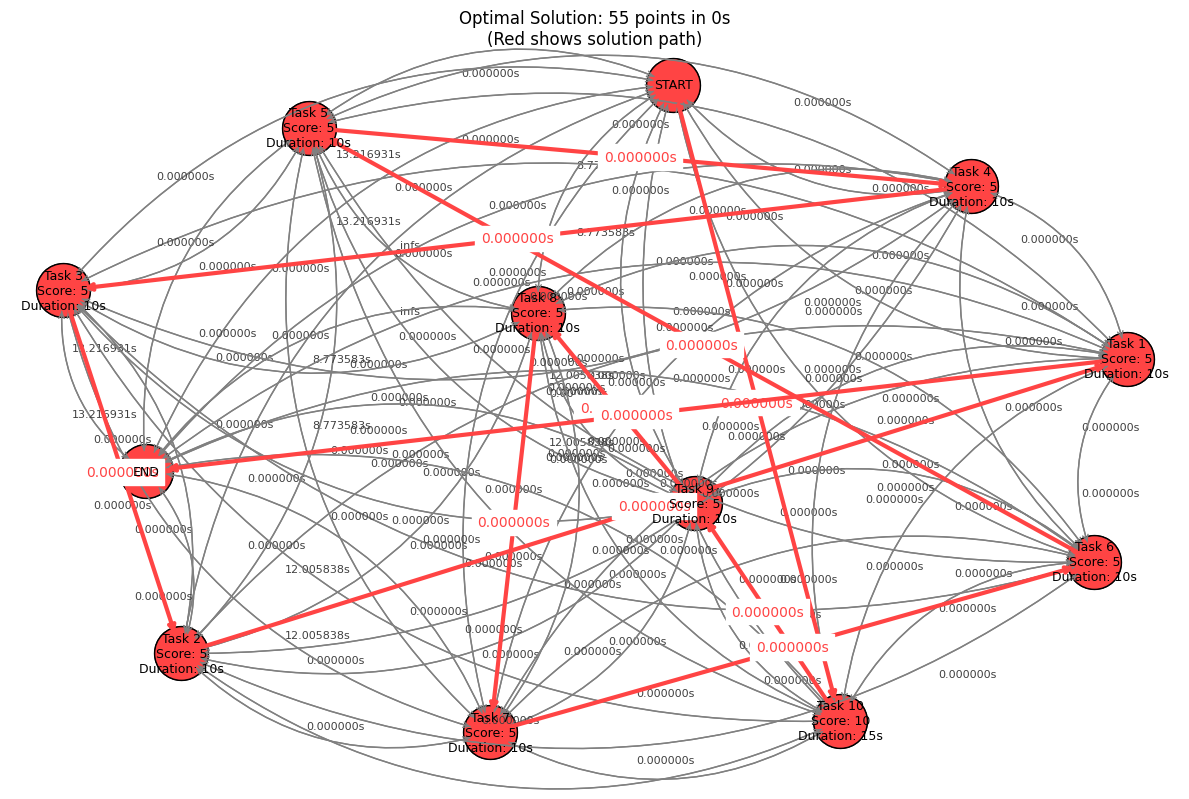

In [48]:
brain.task_planner.visualize_solution(display_all_edges=True)

On observe bien qu'il y a une erreur dans l'estimation des temps de déplacement ou que les param de la config sont erronés car le temp de déplacement demande beaucoup trop de temps.

In [49]:
print(brain.game_tasks_planification)

TaskPlannerSolution with score 55 and duration 0s


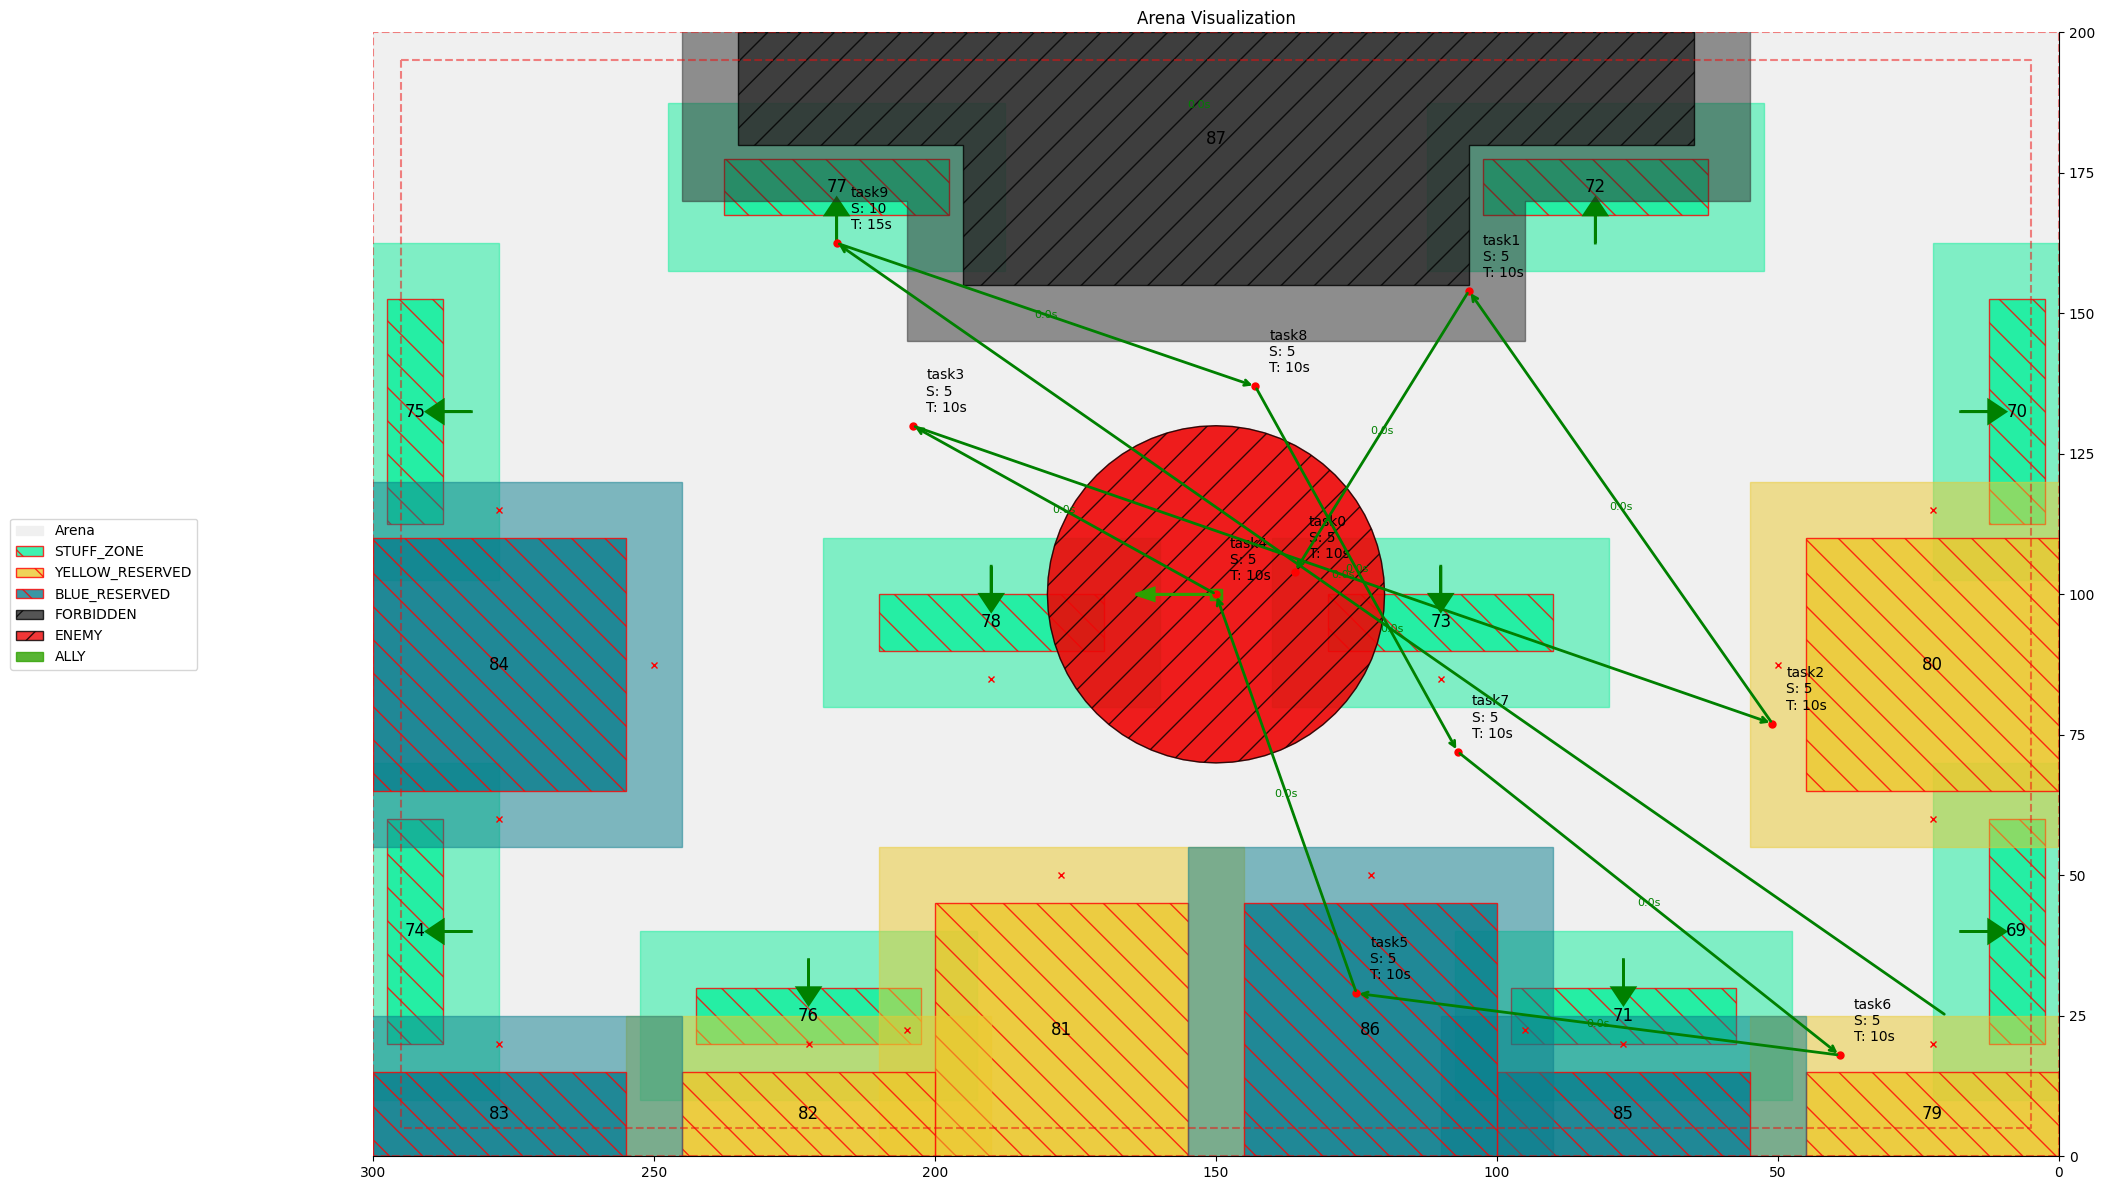

In [51]:
brain.visualize_tasks_in_arena()

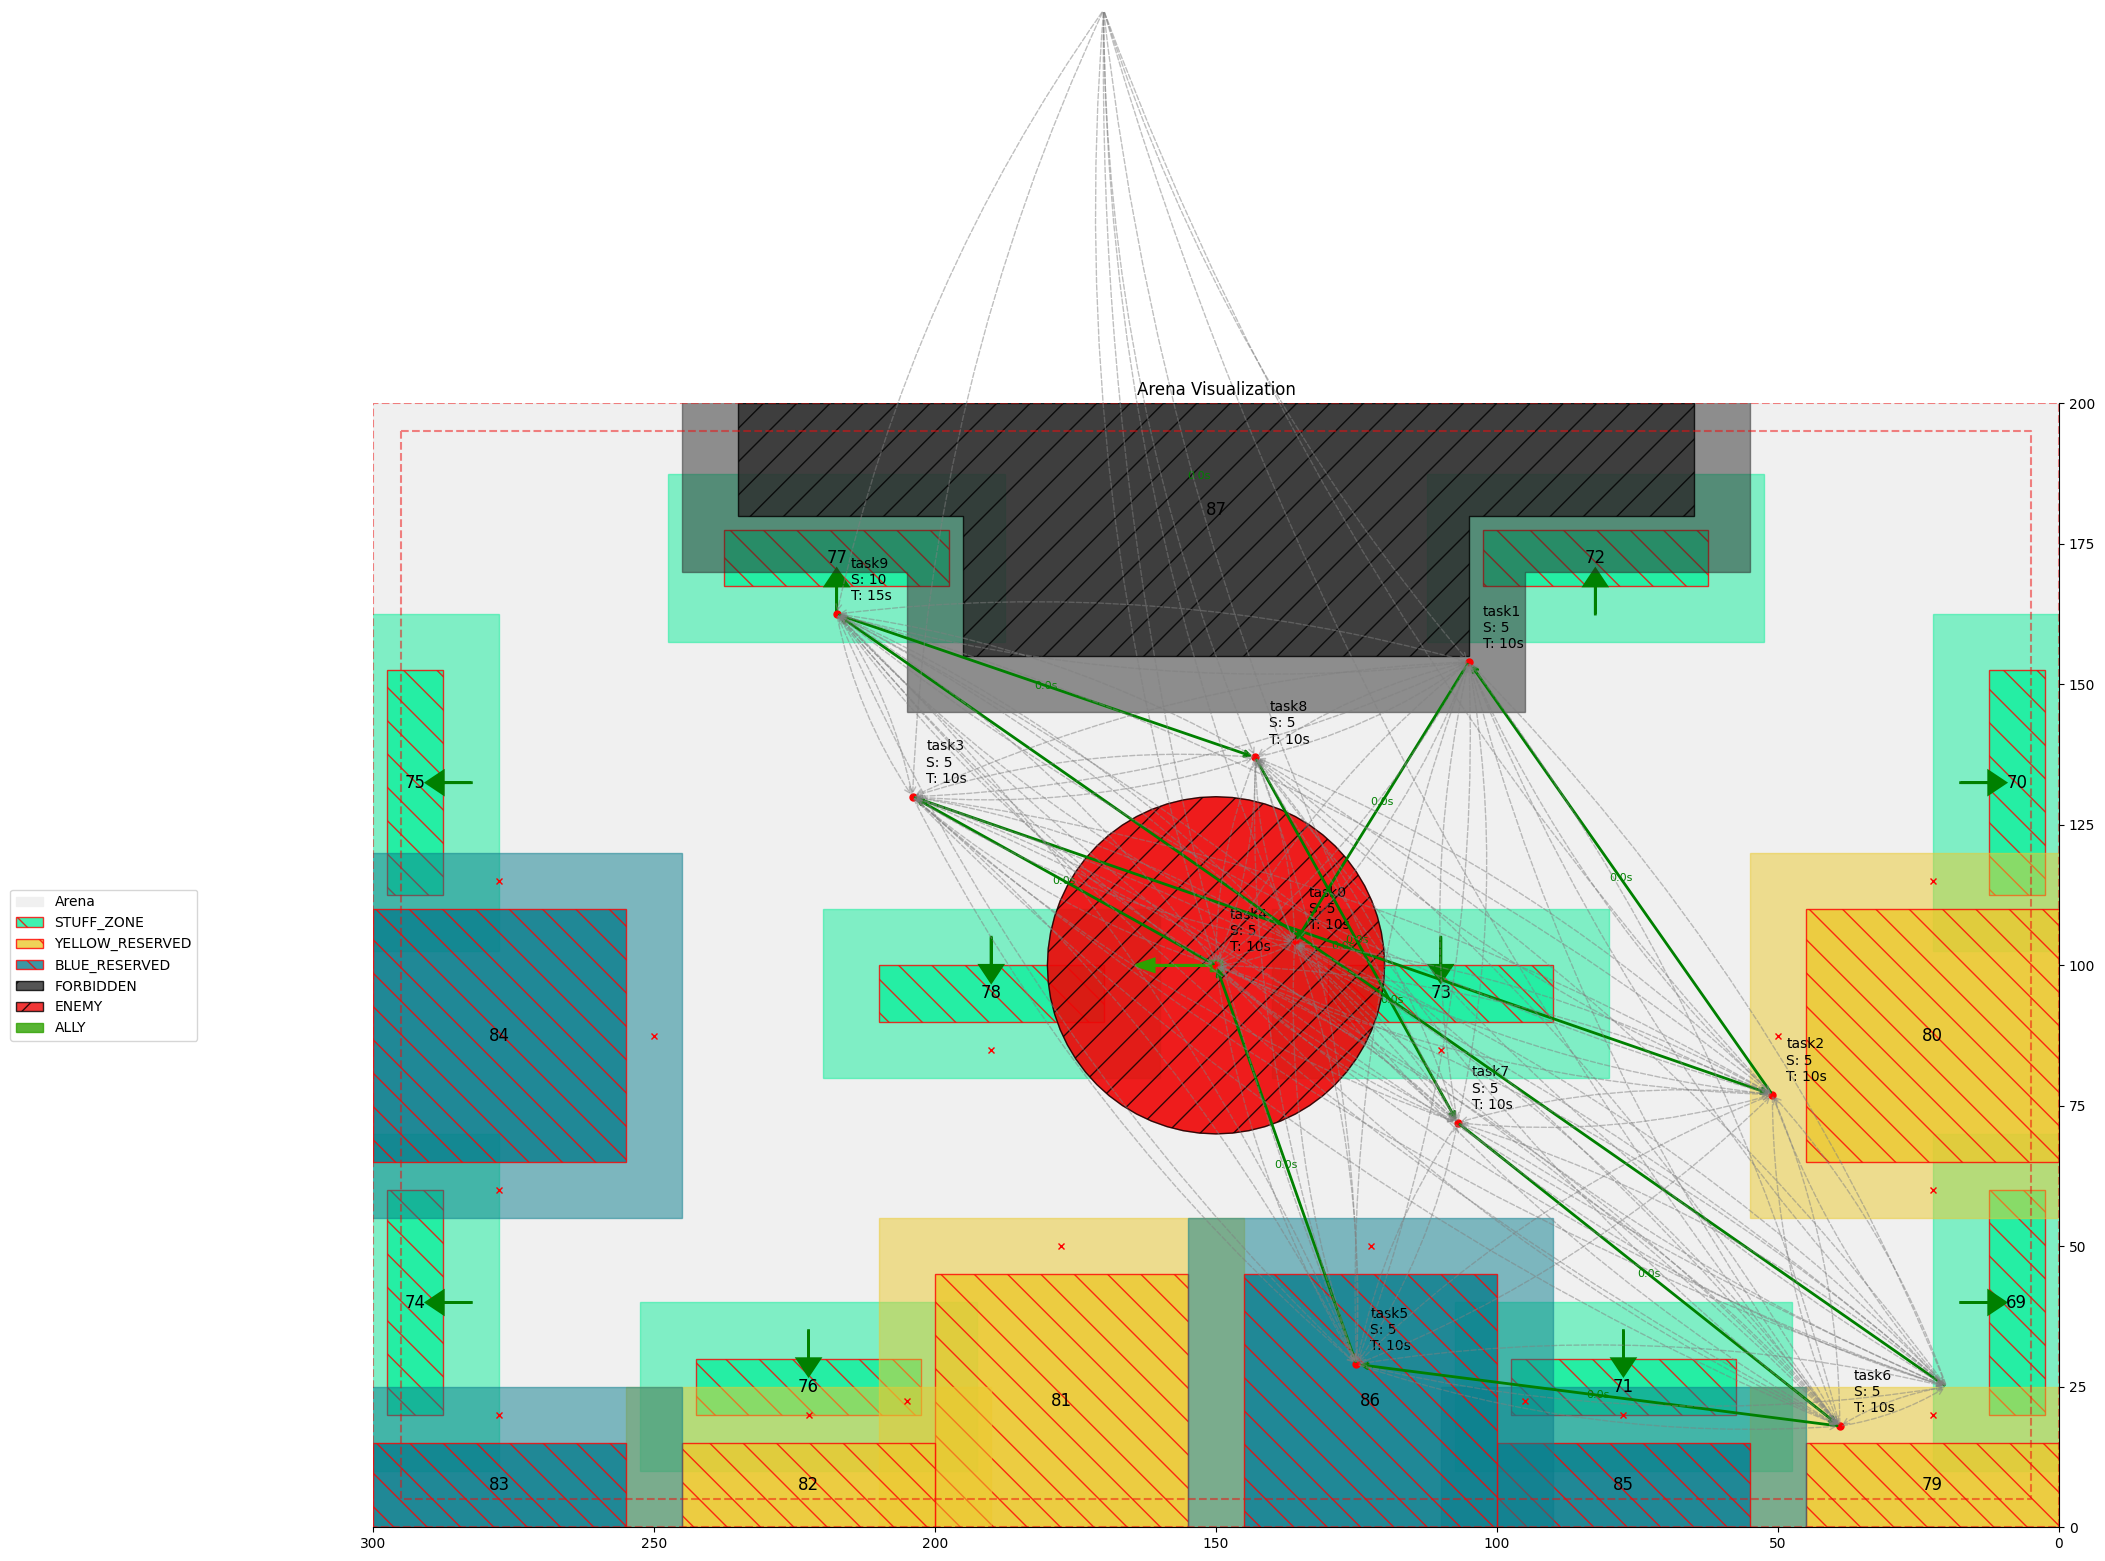

In [50]:
brain.visualize_tasks_in_arena(draw_remaining_edges=True)

Illisible mais permet de remarquer des erreurs de positionnement

Savegarder et charger une solution enregistrées

In [44]:
from tasks import TaskPlannerSolution,TaskPlanner

solution = TaskPlannerSolution.load_solution("task_planner_solution.json")
print(solution)

TaskPlannerSolution with score 55 and duration 0s


Un trajet irréalisable retourne un temps de trajet (je ne sais pas à quoi ce dernier fais réference) au lieu de +infini (int max)

In [52]:
brain.task_planner.travels_duration_matrix_sec

[[0,
  0.0,
  0.0,
  13.216931234022205,
  0.0,
  0.0,
  0.0,
  12.005837769688515,
  8.773582879356429,
  0.0,
  0,
  inf],
 [0.0, 0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0, 0.0],
 [0.0, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0],
 [13.216931234022205, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 13.216931234022205],
 [0.0, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0],
 [0.0, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0],
 [0.0, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0],
 [12.005837769688515, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12.005837769688515],
 [8.773582879356429, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8.773582879356429],
 [0.0, 0.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [inf,
  0.0,
  0.0,
  13.216931234022205,
  0.0,
  0.0,
  0.0,
  12.005837769688515,
  8.773582879356429,
  0.0,
  0,
  0]]

# Actionneurs

In [1]:

from config_loader import CONFIG
from controllers.actuators_controller import ActuatorsController
from loggerplusplus import Logger
import time
actuator_manager = ActuatorsController(
    ser=12677020,
    logger=Logger(identifier="actuator_manager")
)

ModuleNotFoundError: No module named 'rolling_basis'

In [6]:
def demo_servo():
    actuator_manager.update_servo(pin=1,angle=90)
    time.sleep(1)
    actuator_manager.update_servo(pin=1,angle=0)
    time.sleep(1)
    actuator_manager.update_servo(pin=1,angle=90)
    time.sleep(1)
    actuator_manager.update_servo(pin=1,angle=0)
    
def demo_servo_detach():
    actuator_manager.update_servo(pin=1,angle=90,detach=True)
    time.sleep(1)
    actuator_manager.update_servo(pin=1, angle=0, detach=True)

In [11]:
demo_servo()

14:26:41.952318 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=90, min_angle=0, max_angle=180, detach=False, detach_delay=1000) called
14:26:42.956426 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=0, min_angle=0, max_angle=180, detach=False, detach_delay=1000) called
14:26:43.959025 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=90, min_angle=0, max_angle=180, detach=False, detach_delay=1000) called
14:26:44.961769 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=0, min_angle=0, max_angle=180, detach=False, detach_delay=1000) called


In [12]:
demo_servo_detach()

14:26:52.083142 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=90, min_angle=0, max_angle=180, detach=True, detach_delay=1000) called
14:26:53.086892 -> [Actuators] [decorators.py:67]   DEBUG    | [__main__] ActuatorsManager.update_servo(self=<controllers..., pin=1, angle=0, min_angle=0, max_angle=180, detach=True, detach_delay=1000) called
